In [2]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar

In [4]:
# Set magics
# use autoreload to only reload the user-written functions 
%load_ext autoreload
%autoreload 1

%aimport model 
%aimport nosharing
%aimport testsym
# %aimport vareps
# %aimport baseline
# ^can be taken into usee when needed; they're in a separate folder, need to be taken out first

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



Parameter values

In [201]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.2, 25) # search cost (avoid 0 exactly)
prev_p1, prev_p2 = 0.5, 0.5
sigma = 0.5

# Baseline model

In [206]:
mu = 1
gamma = 0
results_base = model.equilibrium_path_s_eps(eps_grid, s_grid, gamma, mu, sigma, prev_p1, prev_p2)
df = pd.DataFrame(results_base)
df["Theta"] = df["Theta"].clip(0, 1)

In [194]:
np.sum((df['interior'] == True))

90

In [140]:
# Keeping only the interior solutions
df_int = df[df['interior'] == True]

In [141]:
df_int.head(72)

,eps,s,p1,p2,Theta,interior,converged
1,0.000000,0.009292,0.500191,0.500191,6.276717e-07,True,False
2,0.000000,0.017583,0.487841,0.487839,1.310672e-06,True,False
3,0.000000,0.025875,0.479012,0.479009,1.599599e-06,True,False
4,0.000000,0.034167,0.471924,0.471921,1.618850e-06,True,False
6,0.000000,0.050750,0.460544,0.460542,4.470695e-07,True,False
7,0.000000,0.059042,0.455698,0.455696,8.357218e-07,True,False
8,0.000000,0.067333,0.451220,0.451218,7.541929e-07,True,False
9,0.000000,0.075625,0.447024,0.447023,1.630581e-07,True,False
10,0.000000,0.083917,0.443046,0.443041,9.790896e-07,True,False
11,0.000000,0.092208,0.439246,0.439245,2.482472e-07,True,False


# Variable Epsilon

$\mu=0.75$ - variable epsilon in play.

In [207]:
mu = 0.75
gamma = 0
results_vareps = model.equilibrium_path_s_eps(eps_grid, s_grid, gamma, mu, sigma, prev_p1, prev_p2)
df_vareps = pd.DataFrame(results_vareps)
df_vareps["Theta"] = df_vareps["Theta"].clip(0, 1)

# Figures to compare baseline and variable epsilon
**Colorbar**


Baseline

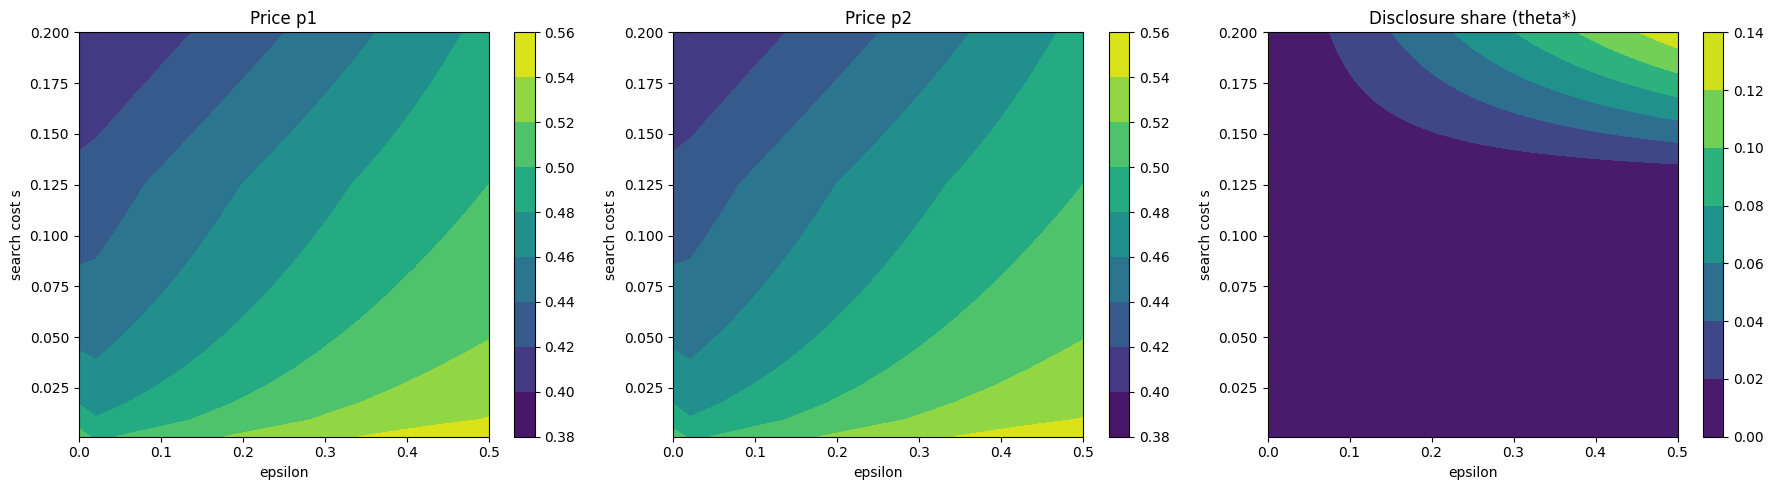

In [203]:
model.plot_colorblock(df, eps_grid, s_grid)

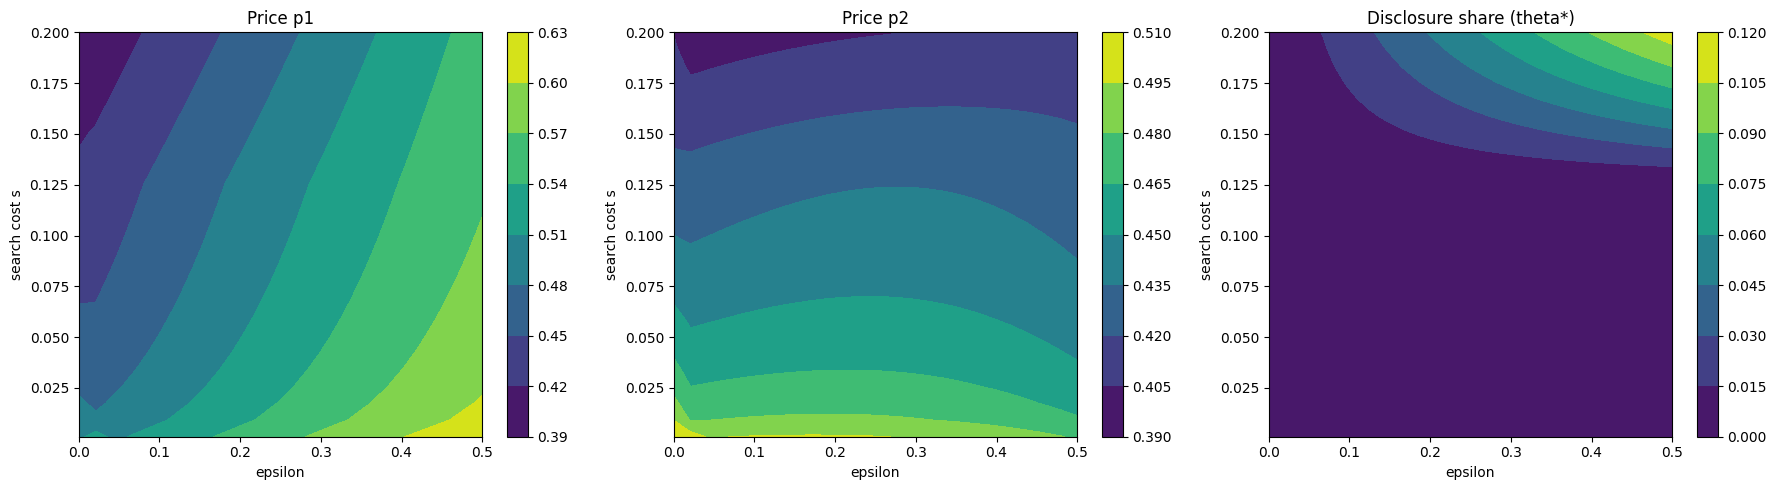

In [208]:
model.plot_colorblock(df_vareps, eps_grid, s_grid)

Variable epsilon

**Separate cases: functions of $\varepsilon$**

In [52]:
# Shared parameters
eps_grid = np.linspace(0.0, 0.5, 25)
s_values = [0.1, 0.15, 0.2]
p1_init, p2_init = 0.5, 0.5

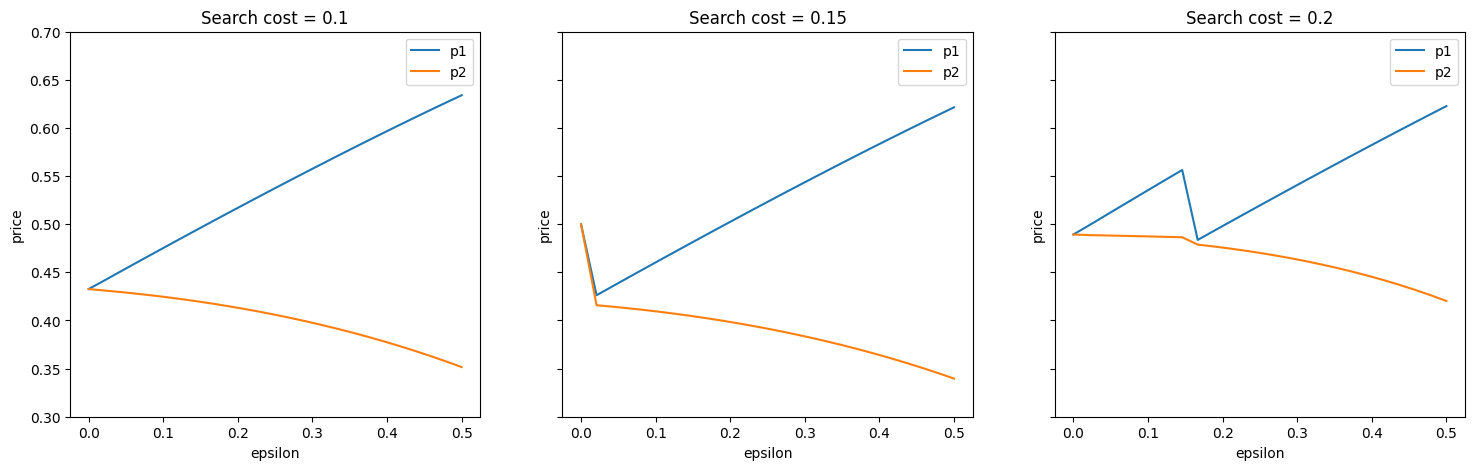

In [53]:
# baseline
gamma = 0
mu = 1
model.plot_price_curves(eps_grid, s_values, gamma, mu, p1_init, p2_init)

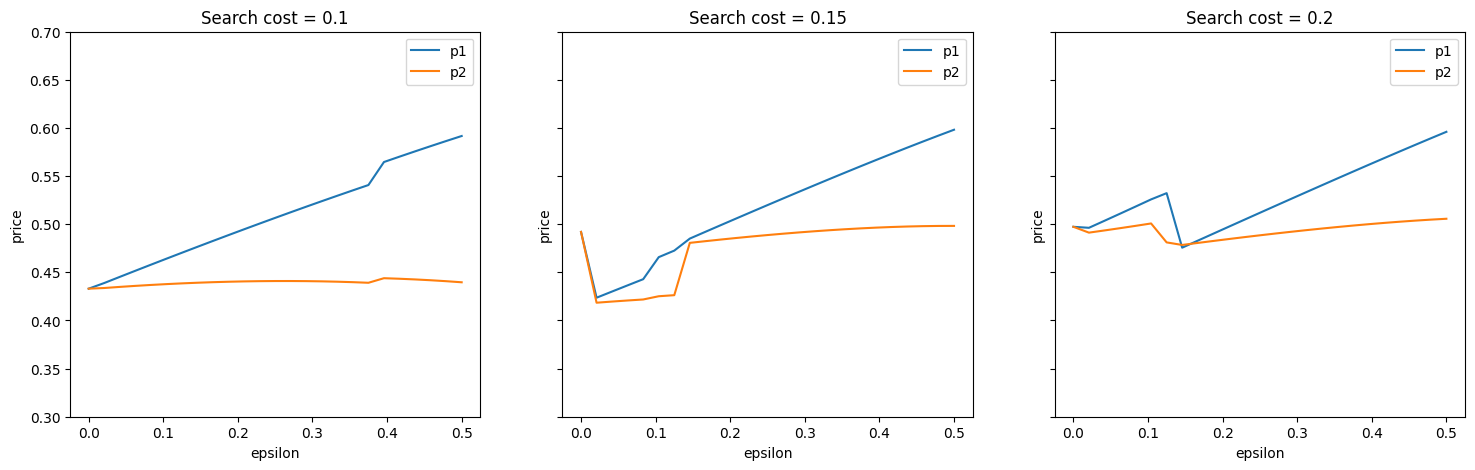

In [54]:
# variable epsilon
gamma = 0
mu = 0.75
model.plot_price_curves(eps_grid, s_values, gamma, mu, p1_init, p2_init)

# Baseline with naïvete

In [55]:
# Define parameter cases #
gamma_grid = np.linspace(0, 1, 50)

cases = [
    (0.1, 0.1),
    (0.2, 0.1),
    (0.2, 0.2),
    (0.2, 0.3)
]

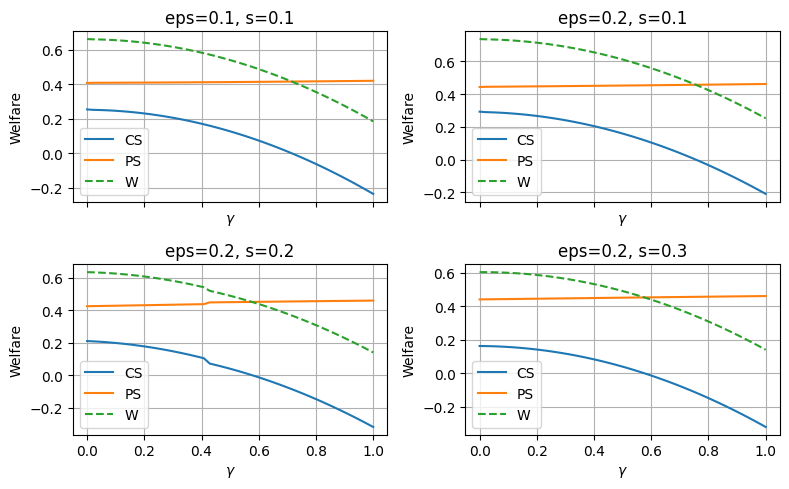

In [56]:
# baseline with naïvete
mu = 1
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu)
    ax.plot(gamma_grid, CS, label="CS")
    ax.plot(gamma_grid, PS, label="PS")
    ax.plot(gamma_grid, W, linestyle="--", label="W")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

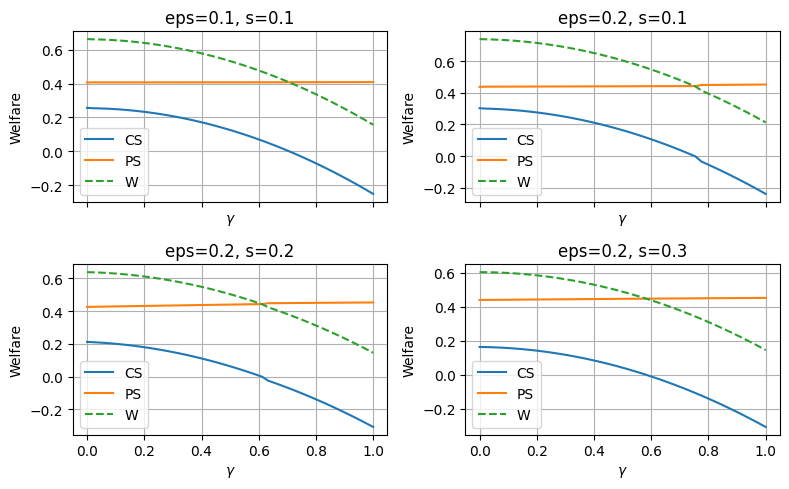

In [57]:
# variable epsilon with naïvete
mu = 0.75
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu)
    ax.plot(gamma_grid, CS, label="CS")
    ax.plot(gamma_grid, PS, label="PS")
    ax.plot(gamma_grid, W, linestyle="--", label="W")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

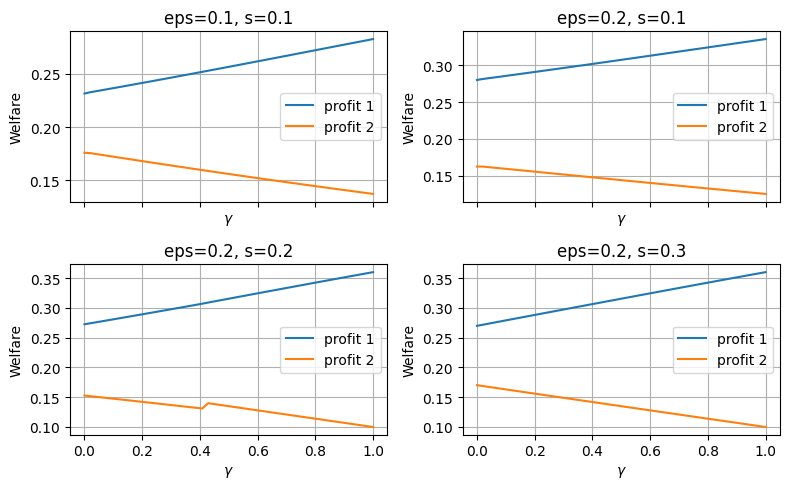

In [58]:
# baseline with naïvete
mu = 1
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu)
    ax.plot(gamma_grid, pi1, label="profit 1")
    ax.plot(gamma_grid, pi2, label="profit 2")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

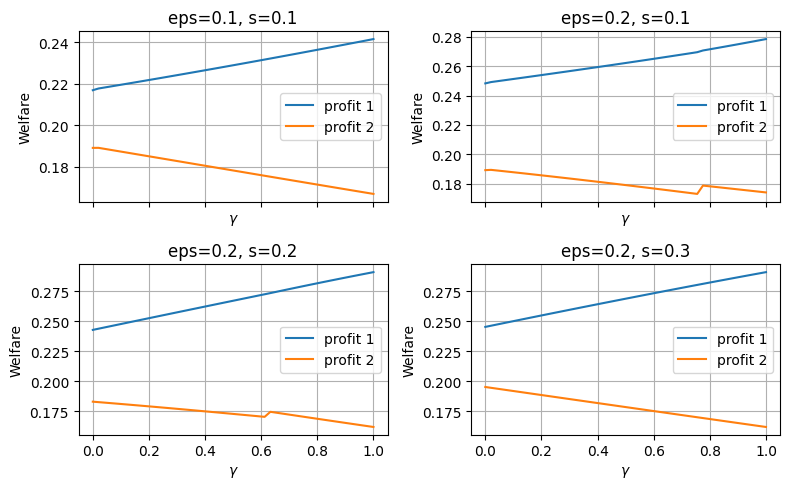

In [59]:
# variable epsilon with naïvete
mu = 0.75
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu)
    ax.plot(gamma_grid, pi1, label="profit 1")
    ax.plot(gamma_grid, pi2, label="profit 2")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [60]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.2, 25) # search cost (avoid 0 exactly)
results_nosharing = []
p1_init, p2_init = 0.5, 0.5

In [166]:
eps, s = 0.2, 0.15
mu = 1
p1, p2, converged = nosharing.solve_equilibrium(eps, s, mu)
check = nosharing.check_interior(p1, p2, eps, s)

print(p1, p2)
print(check)

0.5044482625834389 0.40117373991249156
{'z_positive': True, 'support_ok': True, 'interior': True}


In [167]:
eps, s = 0.2, 0.15
p1, p2, converged = ekstra.solve_equilibrium(eps, s)
check = ekstra.check_interior(p1, p2, eps, s)

print(p1, p2)
print(check)

0.5044482625834389 0.40117373991249156
{'z_positive': True, 'support_ok': True, 'interior': True}


In [209]:
def compute_outcomes(eps, s, mu, sigma):

    results = {}

    # --- No sharing ---
    p1_ns, p2_ns, _ = nosharing.solve_equilibrium(eps, s, mu)
    pi1_ns = nosharing.profit1(p1_ns, p2_ns, eps, s, mu)
    pi2_ns = nosharing.profit2(p1_ns, p2_ns, eps, s, mu)

    results["No Sharing"] = {
        "p1": p1_ns,
        "p2": p2_ns,
        "pi1": pi1_ns,
        "pi2": pi2_ns,
        "CS": nosharing.consumer_surplus(p1_ns, p2_ns, eps, s, mu),
        "PS": pi1_ns + pi2_ns,
        "W": nosharing.total_welfare(p1_ns, p2_ns, eps, s, mu)
    }

    # --- Sharing, rational ---
    p1_r, p2_r, _ = model.solve_equilibrium(eps, s, gamma=0, mu=mu, sigma=sigma)
    pi1_r = model.profit1(p1_r, p2_r, eps, s, gamma=0, mu=mu, sigma=sigma)
    pi2_r = model.profit2(p1_r, p2_r, eps, s, gamma=0, mu=mu, sigma=sigma)

    results["Sharing (γ=0)"] = {
        "p1": p1_r,
        "p2": p2_r,
        "pi1": pi1_r,
        "pi2": pi2_r,
        "CS": model.consumer_surplus(p1_r, p2_r, eps, s, gamma=0, mu=mu, sigma=sigma),
        "PS": pi1_r + pi2_r,
        "W": model.total_welfare(p1_r, p2_r, eps, s, gamma=0, mu=mu, sigma=sigma)
    }

    # --- Sharing, naive ---
    p1_n, p2_n, _ = model.solve_equilibrium(eps, s, gamma=0.3, mu=mu, sigma=sigma)
    pi1_n = model.profit1(p1_n, p2_n, eps, s, gamma=0.3, mu=mu, sigma=sigma)
    pi2_n = model.profit2(p1_n, p2_n, eps, s, gamma=0.3, mu=mu, sigma=sigma)

    results["Sharing (γ=0.3)"] = {
        "p1": p1_n,
        "p2": p2_n,
        "pi1": pi1_n,
        "pi2": pi2_n,
        "CS": model.consumer_surplus(p1_n, p2_n, eps, s, gamma=0.3, mu=mu, sigma=sigma),
        "PS": pi1_n + pi2_n,
        "W": model.total_welfare(p1_n, p2_n, eps, s, gamma=0.3, mu=mu, sigma=sigma)
    }

    return pd.DataFrame(results).T

In [216]:
df_base = compute_outcomes(eps=0.5, s=0.19, mu=1, sigma=1)
print(df_base.round(3))

                    p1     p2    pi1    pi2     CS     PS      W
No Sharing       0.616  0.337  0.422  0.101  0.371  0.523  0.894
Sharing (γ=0)    0.611  0.328  0.421  0.098  0.378  0.519  0.897
Sharing (γ=0.3)  0.648  0.314  0.450  0.089  0.313  0.540  0.853


In [219]:
df_eps = compute_outcomes(eps=0.5, s=0.19, mu=0.75, sigma=1)
print(df_eps.round(3))

                    p1     p2    pi1    pi2     CS     PS      W
No Sharing       0.591  0.501  0.359  0.184  0.383  0.544  0.926
Sharing (γ=0)    0.555  0.413  0.326  0.162  0.441  0.488  0.928
Sharing (γ=0.3)  0.593  0.418  0.344  0.158  0.375  0.502  0.877


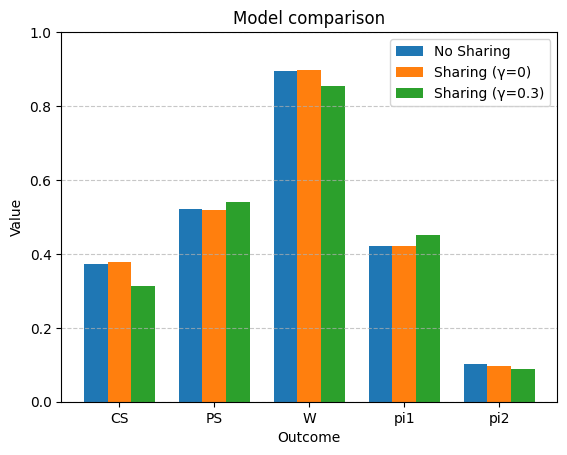

In [218]:
model.plot_welfare_comparison(df_base)

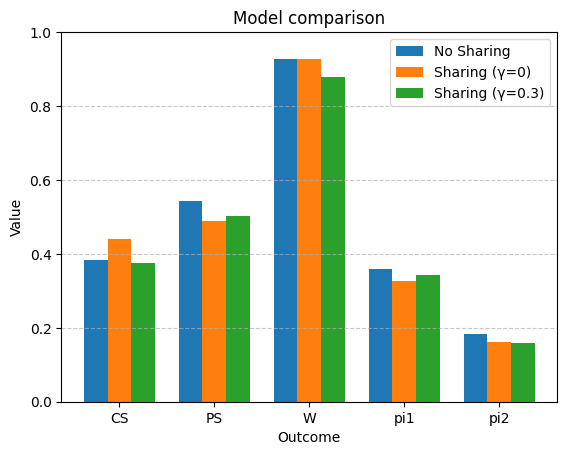

In [221]:
model.plot_welfare_comparison(df_eps)

# Symmetric model

In [204]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid = np.linspace(0.001, 0.2, 25) # search cost (avoid 0 exactly)
results_sym = testsym.equilibrium_path_s_eps(eps_grid, s_grid, sigma=0.5)
df_sym = pd.DataFrame(results_sym)

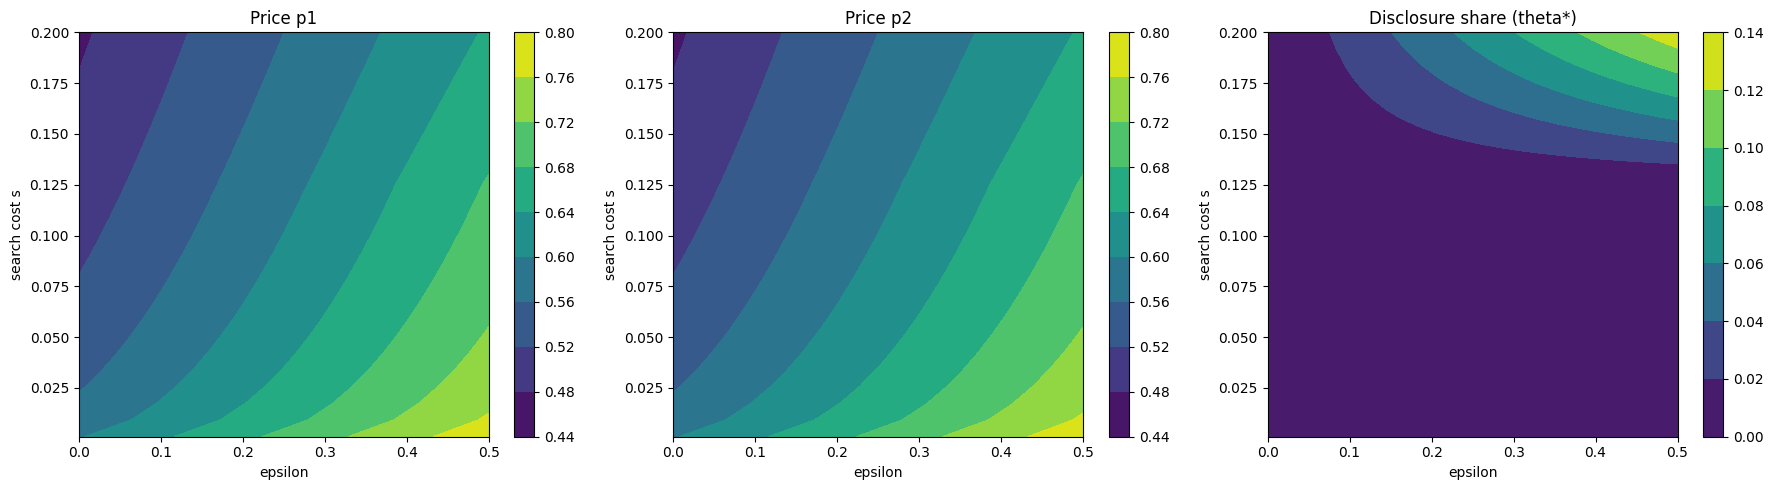

In [205]:
testsym.plot_colorblock(df_sym, eps_grid, s_grid)

In [196]:
eps = 0.3
s = 0.19
p1 = 0.4
p2 = 0.4
p = 0.4
gamma = 0
mu = 0.5
sigma = 0.5

In [177]:
model.theta_star_A(p1, p2, eps, s, gamma, sigma)

0.0349324200890693

In [192]:
model.

0.4753056969660347